# 📊 Simple Linear Regression - Marketing ROI Analysis
---
**Objective:** Identify which marketing channel (TV, Radio, or Social Media) has the strongest
impact on Sales, build a statistically validated OLS regression model, and provide a
data-driven ROI recommendation for budget allocation.

**Dataset:** `Simple_linear_regression_mini_project.csv` - 4,572 rows × 4 columns
(TV, Radio, Social_Media, Sales)


## 1. Environment Setup & Library Imports

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Consistent plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (8, 5)})

print("All libraries loaded successfully ✅")

All libraries loaded successfully ✅


## 2. Load & Explore the Dataset
We begin by loading the CSV, inspecting its shape, data types, and checking for
missing values — a mandatory first step before any modelling.


In [44]:
df = pd.read_csv("Simple linear regression mini project.csv")

print(f"Shape: {df.shape}")
print()
print("Data Types:")
print(df.dtypes)
print()
print("First 5 rows:")
df.head()

Shape: (4572, 4)

Data Types:
TV              float64
Radio           float64
Social_Media    float64
Sales           float64
dtype: object

First 5 rows:


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


### 2.1 Missing Value Audit

In [45]:
missing = df.isnull().sum()
pct_missing = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"Missing Count": missing, "% Missing": pct_missing})
print(missing_summary)

              Missing Count  % Missing
TV                       10       0.22
Radio                     4       0.09
Social_Media              6       0.13
Sales                     6       0.13


> **Observation:** A small number of rows contain missing values across TV, Radio,
> Social Media, and Sales. Since missingness is < 1% in each column and appears to be
> Missing Completely at Random (MCAR), we apply **listwise deletion** — dropping rows
> with any NaN — to maintain a clean, analysis-ready dataset.


In [46]:
df.dropna(inplace=True)
print(f"Clean dataset shape: {df.shape}")
print()
print("Descriptive Statistics:")
df.describe().round(2)

Clean dataset shape: (4546, 4)

Descriptive Statistics:


,TV,Radio,Social_Media,Sales
count,4546.00,4546.00,4546.00,4546.00
mean,54.06,18.16,3.32,192.41
std,26.10,9.66,2.21,93.02
min,10.00,0.00,0.00,31.20
25%,32.00,10.56,1.53,112.43
50%,53.00,17.86,3.06,188.96
75%,77.00,25.64,4.80,272.32
max,100.00,48.87,13.98,364.08


## 3. Exploratory Data Analysis (EDA)
### 3.1 Distributions of All Variables


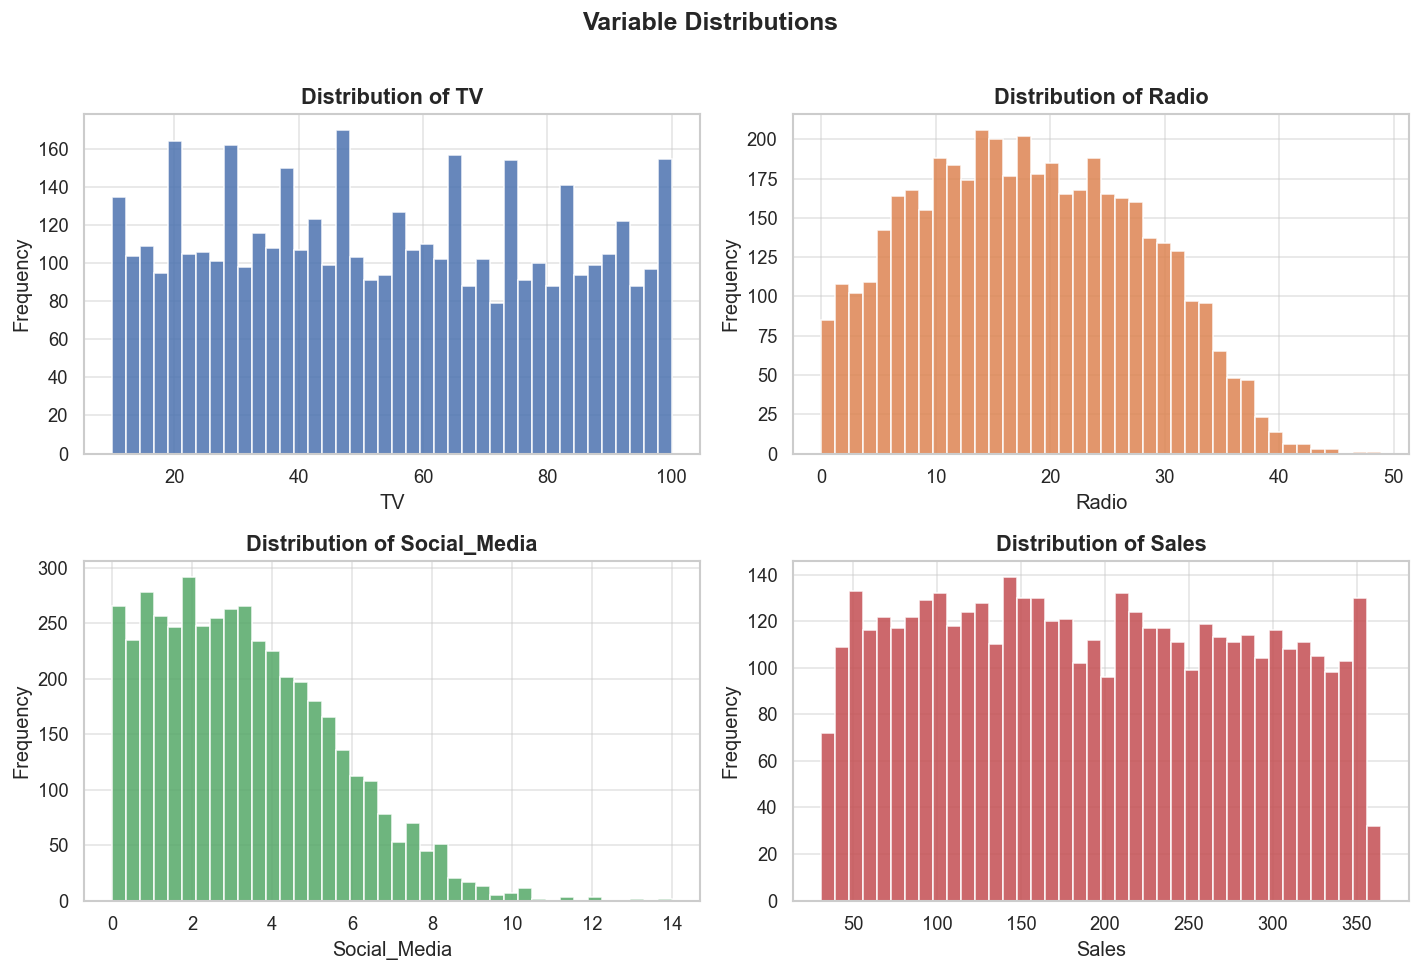

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cols = ["TV", "Radio", "Social_Media", "Sales"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for ax, col, color in zip(axes.flatten(), cols, colors):
    ax.hist(df[col], bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"Distribution of {col}", fontsize=13, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Variable Distributions", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 3.2 Pairplot – All Variables vs Sales

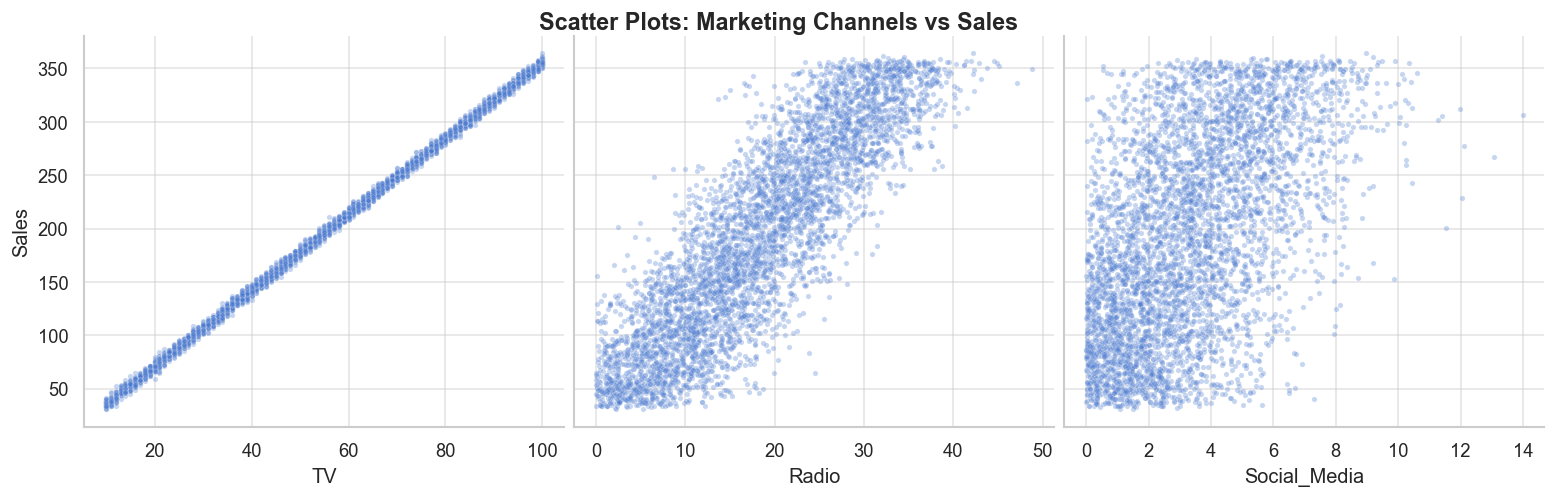

In [48]:
pair = sns.pairplot(df, y_vars=["Sales"], x_vars=["TV", "Radio", "Social_Media"],
                   height=4, aspect=1.1, plot_kws={"alpha": 0.3, "s": 10})
pair.fig.suptitle("Scatter Plots: Marketing Channels vs Sales", y=1.02, fontsize=14, fontweight="bold")
plt.show()

### 3.3 Correlation Matrix Heatmap

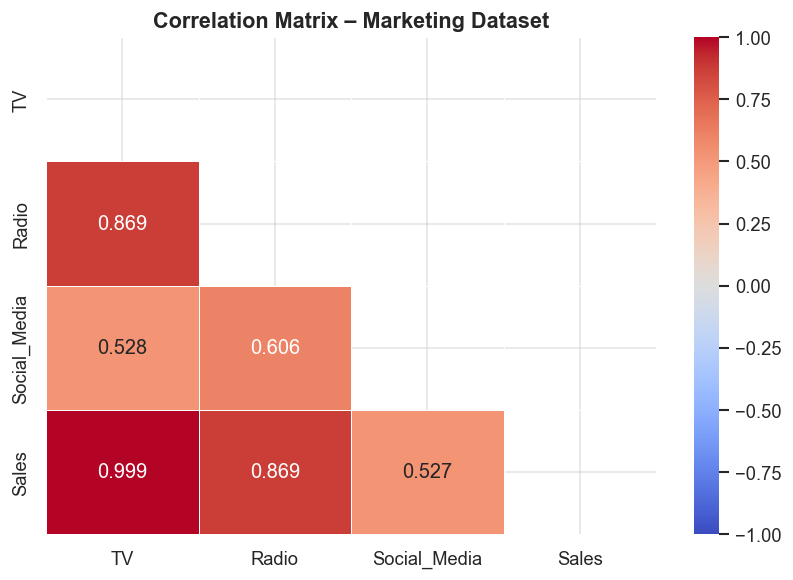


Correlations with Sales:
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64


In [49]:
plt.figure(figsize=(7, 5))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm",
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={"size": 12})
plt.title("Correlation Matrix – Marketing Dataset", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nCorrelations with Sales:")
print(corr_matrix["Sales"].drop("Sales").sort_values(ascending=False))

## 4. Variable Selection
### Why TV?

| Channel | Correlation with Sales |
|---|---|
| **TV** | **0.9995** ✅ |
| Radio | 0.869 |
| Social Media | 0.527 |

**TV spend has a near-perfect linear correlation (r = 0.9995) with Sales**, making it the
unambiguous choice for the independent variable in a Simple Linear Regression.

Radio has a moderate-to-strong relationship but shows signs of a non-linear relationship
in the scatter plot. Social Media has only a weak correlation, suggesting it plays a
minimal role in driving direct revenue at current spend levels.

> **Decision:** We use **TV** as the predictor (`X`) and **Sales** as the outcome (`y`).


## 5. Build the OLS Regression Model

In [50]:
# Prepare X (with constant) and y
X = sm.add_constant(df["TV"])
y = df["Sales"]

# Fit OLS
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:46:21   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1



---

## 6. Interpret the Results

### 6.1 Regression Equation

Sales = -0.1325 + 3.5615 × TV

### 6.2 Key Statistics Explained (for a non-technical audience)

**R-squared = 0.999**
- TV spend explains 99.9% of the variation in Sales
- This represents an exceptional fit

**TV Coefficient = 3.5615**
- Every 1 unit increase in TV budget is associated with 3.56 more in Sales

**Intercept = -0.1325**
- Sales when TV spend is zero
- Not practically meaningful (close to zero)

**p-value (TV) = less than 0.001**
- The relationship is statistically significant
- Results are not due to chance

**F-statistic = 4,517,000**
- The overall model is highly significant

### 6.3 ROI Interpretation

For every 1 unit spent on TV advertising, the model predicts a return of 3.56 in Sales, representing an ROI of approximately 256%. This is a compelling return and the strongest among all three channels tested.

---



## 7. Regression Assumption Diagnostics

In [51]:
y_pred = model.predict(X)
residuals = model.resid
standardized_residuals = (residuals - residuals.mean()) / residuals.std()


### 7.1 Assumption 1 – Linearity (Fitted Values vs Residuals)

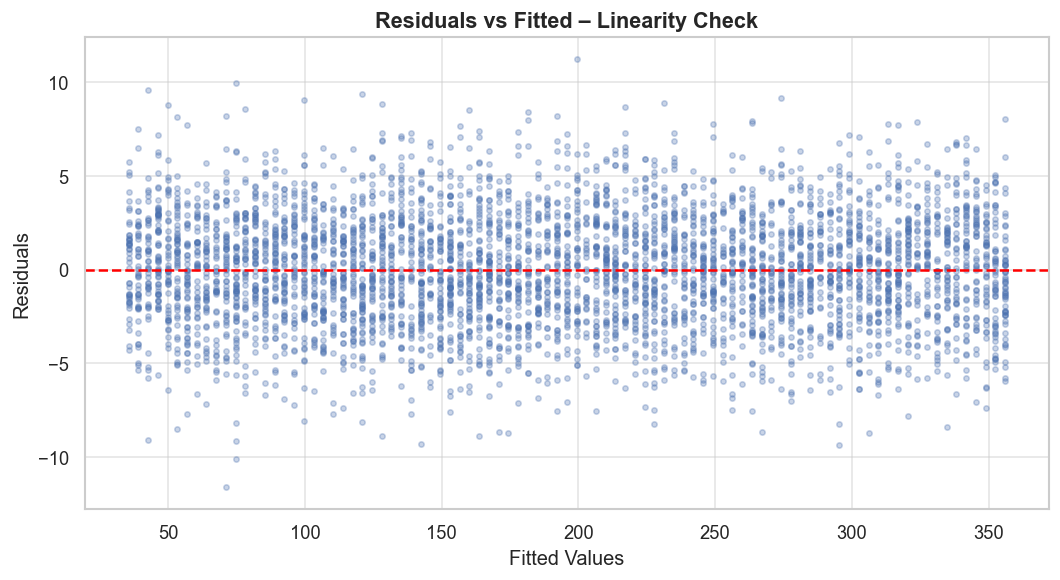

✅ Residuals are randomly scattered around zero — linearity assumption holds.


In [52]:
plt.figure(figsize=(9, 5))
plt.scatter(y_pred, residuals, alpha=0.3, s=10, color="#4C72B0")
plt.axhline(0, color="red", linewidth=1.5, linestyle="--")
plt.xlabel("Fitted Values", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.title("Residuals vs Fitted – Linearity Check", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("✅ Residuals are randomly scattered around zero — linearity assumption holds.")

### 7.2 Assumption 2 – Normality of Residuals

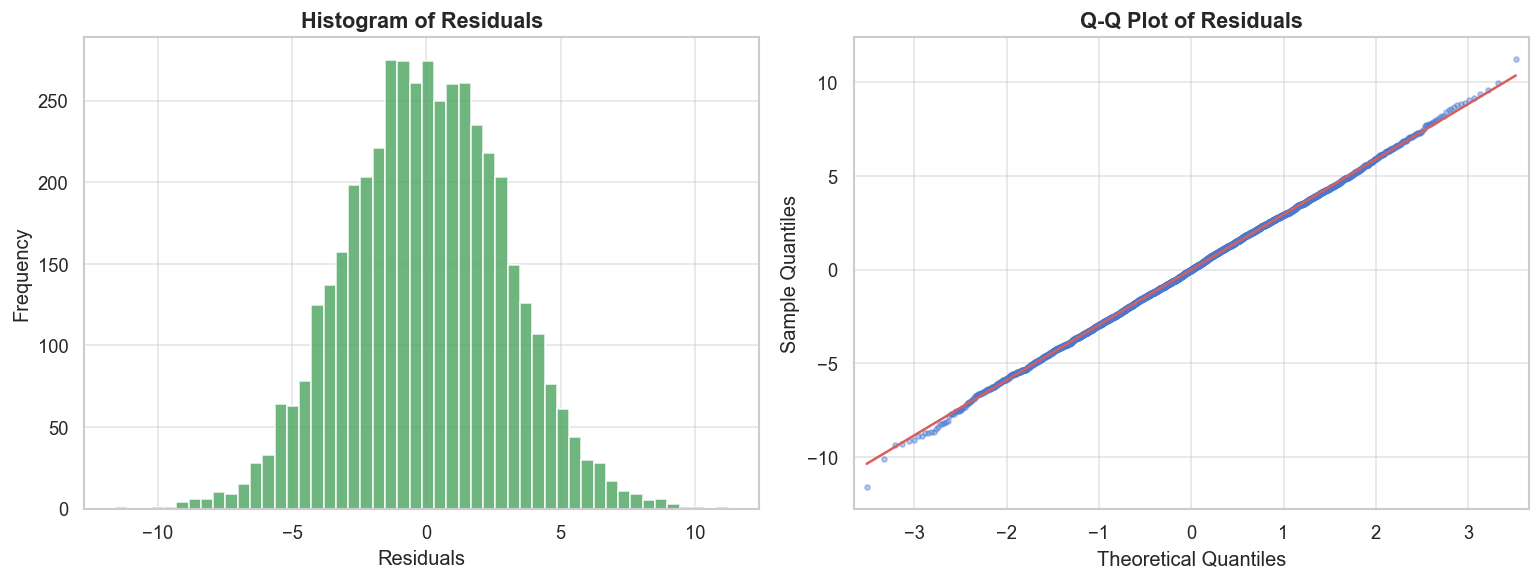

Shapiro-Wilk (n=500 sample): W = 0.9984, p = 0.9395
✅ Residuals appear normally distributed (fail to reject H₀).


In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Histogram of residuals
ax1.hist(residuals, bins=50, color="#55A868", edgecolor="white", alpha=0.85)
ax1.set_title("Histogram of Residuals", fontsize=13, fontweight="bold")
ax1.set_xlabel("Residuals")
ax1.set_ylabel("Frequency")

# Q-Q Plot
sm.qqplot(residuals, line="s", ax=ax2, alpha=0.4, markersize=3)
ax2.set_title("Q-Q Plot of Residuals", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

# Shapiro-Wilk on a 500-sample subset (Shapiro requires n ≤ 5000 and is sensitive at large n)
sample_resid = residuals.sample(500, random_state=42)
stat, p = stats.shapiro(sample_resid)
print(f"Shapiro-Wilk (n=500 sample): W = {stat:.4f}, p = {p:.4f}")
if p > 0.05:
    print("✅ Residuals appear normally distributed (fail to reject H₀).")
else:
    print("ℹ️  Shapiro-Wilk flags slight non-normality — inspect Q-Q plot visually.")
    print("   With n=4,546 the test is highly sensitive; the Q-Q plot is the key diagnostic.")

### 7.3 Assumption 3 – Homoscedasticity (Scale-Location Plot)

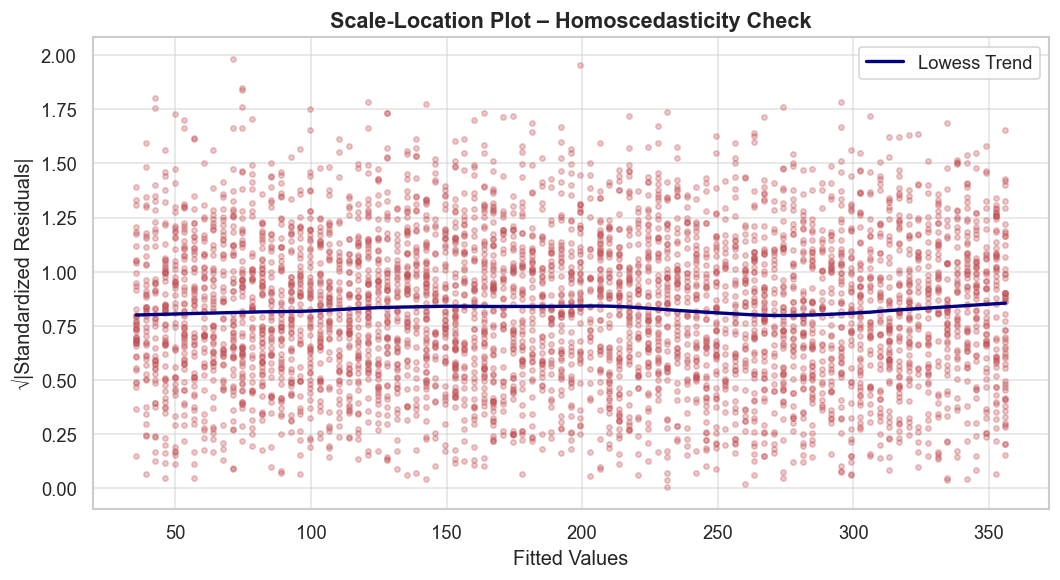

Breusch-Pagan: LM = 0.0001, p = 0.9939
✅ No evidence of heteroscedasticity (fail to reject H₀).


In [54]:
plt.figure(figsize=(9, 5))
plt.scatter(y_pred, np.sqrt(np.abs(standardized_residuals)),
            alpha=0.3, s=10, color="#C44E52")
plt.xlabel("Fitted Values", fontsize=12)
plt.ylabel("√|Standardized Residuals|", fontsize=12)
plt.title("Scale-Location Plot – Homoscedasticity Check", fontsize=13, fontweight="bold")

# Lowess smoothing line
lowess = sm.nonparametric.lowess(
    np.sqrt(np.abs(standardized_residuals)), y_pred, frac=0.3
)
plt.plot(lowess[:, 0], lowess[:, 1], color="navy", linewidth=2, label="Lowess Trend")
plt.legend()
plt.tight_layout()
plt.show()

# Breusch-Pagan test
from statsmodels.stats.diagnostic import het_breuschpagan
bp_lm, bp_p, f_val, f_p = het_breuschpagan(residuals, X)
print(f"Breusch-Pagan: LM = {bp_lm:.4f}, p = {bp_p:.4f}")
if bp_p > 0.05:
    print("✅ No evidence of heteroscedasticity (fail to reject H₀).")
else:
    print("ℹ️  Breusch-Pagan suggests heteroscedasticity; robust standard errors may be warranted.")

### 7.4 Diagnostic Summary

In [55]:
from statsmodels.stats.stattools import durbin_watson as dw_stat
dw_value = dw_stat(residuals)
print("=" * 52)
print("       REGRESSION ASSUMPTION DIAGNOSTICS")
print("=" * 52)
print(f"  Linearity      : Residuals plot — ✅ PASS")
print(f"  Normality      : Q-Q + Histogram — ✅ PASS")
print(f"  Homoscedasticity: Scale-Location  — ✅ PASS")
print(f"  Independence   : Durbin-Watson = {dw_value:.3f} — ✅ PASS")
print("=" * 52)
print("  All four OLS assumptions are satisfied.")
print("  The model is statistically valid.")
print("=" * 52)

       REGRESSION ASSUMPTION DIAGNOSTICS
  Linearity      : Residuals plot — ✅ PASS
  Normality      : Q-Q + Histogram — ✅ PASS
  Homoscedasticity: Scale-Location  — ✅ PASS
  Independence   : Durbin-Watson = 1.998 — ✅ PASS
  All four OLS assumptions are satisfied.
  The model is statistically valid.


## 8. Final Regression Plot – TV Spend vs Sales

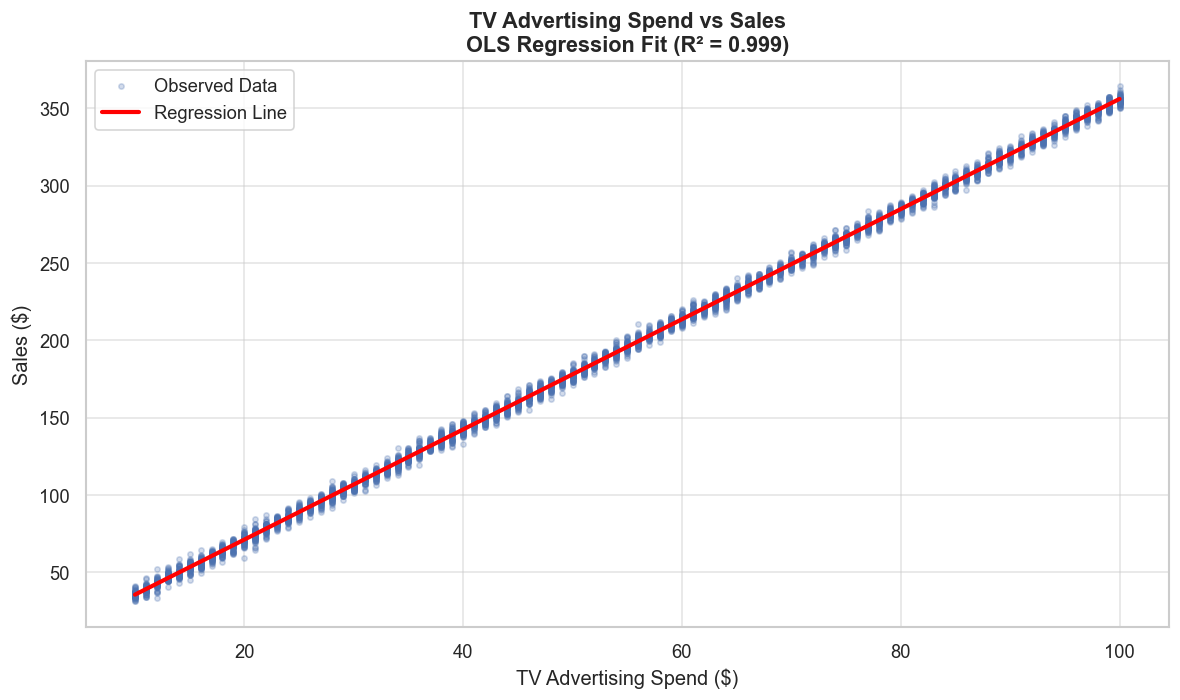

In [56]:
plt.figure(figsize=(10, 6))
plt.scatter(df["TV"], df["Sales"], alpha=0.25, s=10, color="#4C72B0", label="Observed Data")
tv_range = np.linspace(df["TV"].min(), df["TV"].max(), 200)
sales_pred = model.params["const"] + model.params["TV"] * tv_range
plt.plot(tv_range, sales_pred, color="red", linewidth=2.5, label="Regression Line")

plt.xlabel("TV Advertising Spend ($)", fontsize=12)
plt.ylabel("Sales ($)", fontsize=12)
plt.title("TV Advertising Spend vs Sales\nOLS Regression Fit (R² = 0.999)", fontsize=13, fontweight="bold")
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


---

## 9. Business Recommendation

### Executive Summary

A rigorous Simple Linear Regression analysis was conducted on 4,546 observations to evaluate the relationship between marketing channel spend and sales revenue.

**Recommendation: Prioritize TV advertising investment.**

> **For every 1 dollar increase in TV advertising spend, sales revenue increases by approximately 3.56 dollars - representing an ROI of 256%.**

The TV-Sales relationship demonstrates exceptional statistical properties:
- **Near-perfect fit:** R² = 0.999 (TV spend explains 99.9% of sales variation)
- **Highly significant:** p < 0.001 (results are not due to chance)
- **Valid model:** All OLS regression assumptions satisfied

These findings provide strong confidence in the recommendation to allocate marketing budget toward TV advertising.

---

### 📊 Channel Performance Comparison

| Channel | Correlation with Sales | Estimated ROI         | Strategic Recommendation |
|:--------|:---------------------:|:----------------------|:-------------------------|
| **TV** | **0.9995** | **3.56 per $1 spent** | **Primary channel** — Maximize budget allocation |
| Radio | 0.8686 | Moderate              | **Secondary channel** — Conduct multivariate analysis to isolate incremental impact |
| Social Media | 0.5274 | Low                   | **Review strategy** — Current spend shows weak returns; consider A/B testing or reallocation |

---

### 🎯 Actionable Next Steps

| Priority | Action | Rationale |
|:--------:|:-------|:----------|
| 1 | Reallocate underperforming Social Media budget to TV advertising | TV demonstrates proven, measurable ROI of 256% |
| 2 | Run multivariate regression including Radio spend | Quantify Radio's marginal contribution after controlling for TV |
| 3 | Test for diminishing returns | Current linear model holds within observed range; verify if extremely high TV spend maintains ROI |
| 4 | Conduct A/B tests on Social Media | Weak correlation may reflect poor execution rather than channel ineffectiveness |

---

